Generate a simulated two-class data set with 100 observations and
two features in which there is a visible but non-linear separation between the two classes. Show that in this setting, a support vector
machine with a polynomial kernel (with degree greater than 1) or a
radial kernel will outperform a support vector classifier on the training data. Which technique performs best on the test data? Make
plots and report training and test error rates in order to back up
your assertions.

In [15]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.datasets import make_moons

In [54]:
# Generate dataset
X, y = make_moons(n_samples=100,noise=0.1, random_state=42)

print(X.shape)
print(y.shape)

print(X[:5,:5])
print(y[:5])

(100, 2)
(100,)
[[ 1.58202308 -0.44581483]
 [ 0.0660451   0.4392075 ]
 [ 0.73663111 -0.39896339]
 [-1.05692838  0.2424558 ]
 [-0.80216162  0.20271838]]
[1 1 1 0 0]


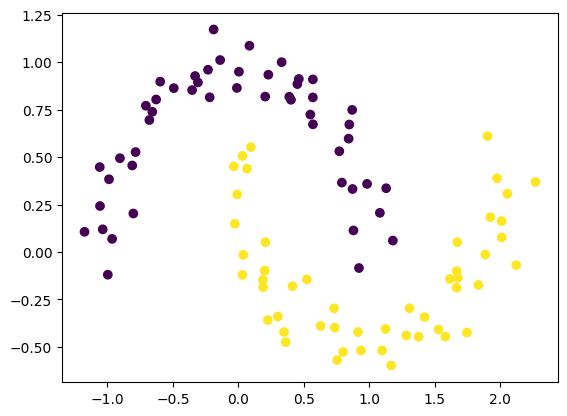

In [8]:
# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [ ]:
def plot_decision_boundary(X, y, clf, ax=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                        np.linspace(y_min, y_max, 500))

    # Predicting
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if ax is None:
        plt.figure(figsize=(8,6))
        ax = plt.gca()

    ax.contourf(xx, yy, Z, alpha=0.1)

    # Plot data
    ax.scatter(X[:, 0], X[:, 1], c=y)
    ax.set_title(str(clf))

In [55]:
boundary = 80
train_X = X[:boundary]
test_X = X[boundary + 1:]
train_y = y[:boundary]
test_y = y[boundary + 1:]

In [56]:
from sklearn import svm
nsvm = svm.SVC(kernel="linear").fit(train_X, train_y)
psvm = svm.SVC(kernel="poly").fit(train_X, train_y)
rsvm = svm.SVC(kernel="rbf").fit(train_X, train_y)

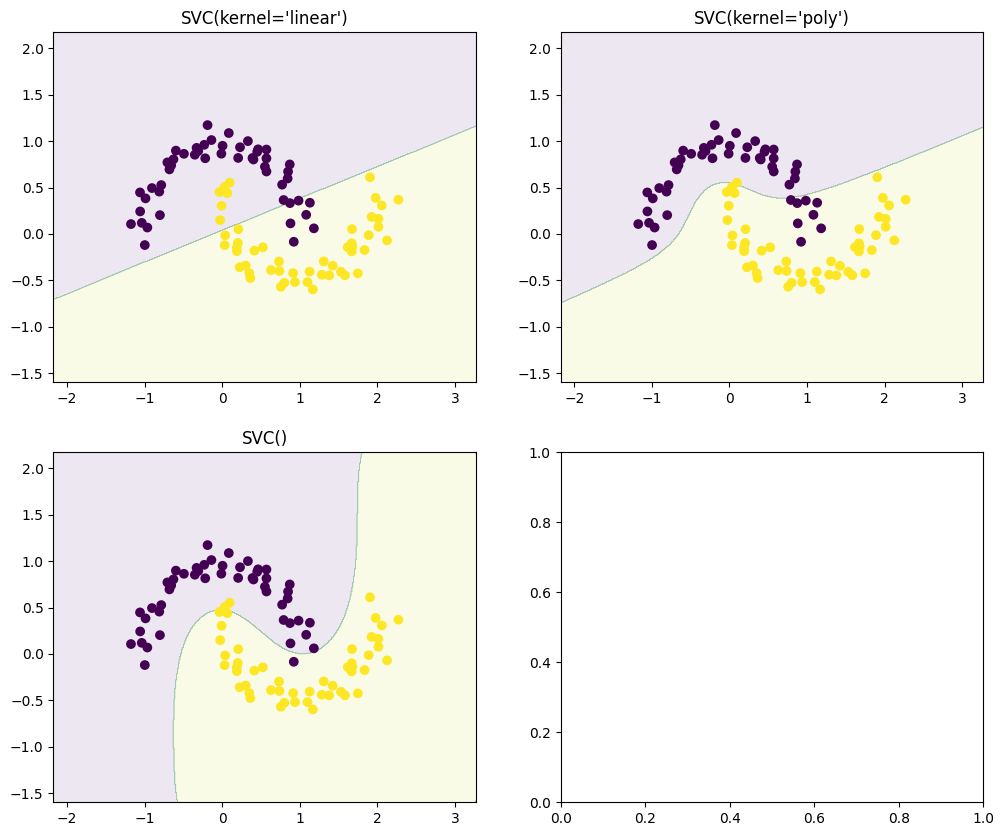

In [57]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

plot_decision_boundary(nsvm, ax=ax1)
plot_decision_boundary(psvm, ax=ax2)
plot_decision_boundary(rsvm, ax=ax3)
plt.show()

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

=======  SVC(kernel='linear') =======
Accuracy: 0.7894736842105263
AUC Score: 0.9432

=======  SVC(kernel='poly') =======
Accuracy: 0.8947368421052632
AUC Score: 0.9318

=======  SVC() =======
Accuracy: 1.0
AUC Score: 1.0000



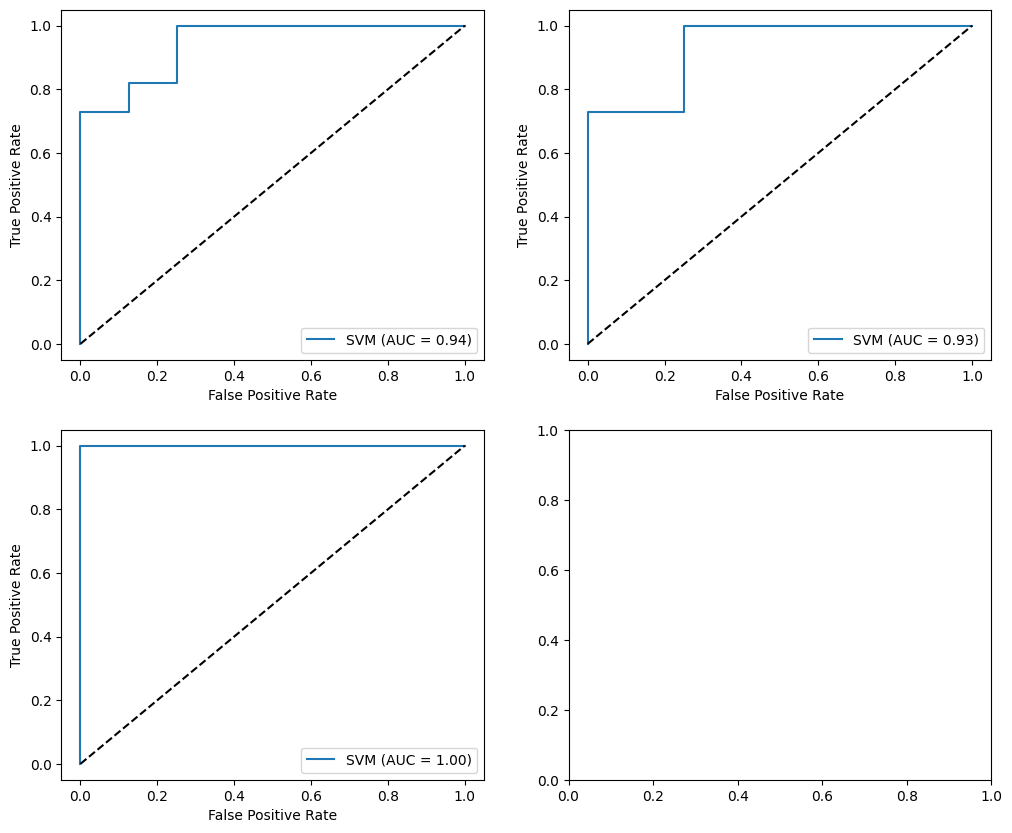

In [58]:
svms = [nsvm, psvm, rsvm]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()


for svm, ax in zip(svms, axes):
    scores = svm.decision_function(test_X)
    print(f"=======  {str(svm)} =======")
    print("Accuracy:", svm.score(test_X, test_y))

    scores = svm.decision_function(test_X)
    auc = roc_auc_score(test_y, scores)
    print(f"AUC Score: {auc:.4f}")

    fpr, tpr, thresholds = roc_curve(test_y, scores)
    ax.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
    ax.plot([0,1], [0,1], "k--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    print()

